# 06 Panel Analysis, Network Spillovers, and Causal Heterogeneity

**Alternative title considered:** 06 Panel Causal Identification and Network Analysis

**Required upstream notebooks:**
- NB02 `02_composite_index_construction.ipynb` produces `outputs/03c/composite_gpr_panel.parquet`
- NB03 `03_instrument_diagnostics_and_macro_merge.ipynb` produces `outputs/04_diagnostics/master_panel_with_gpr.csv`
- NB05 `05_dml_quantile_iv_lp_clean.ipynb` provides the single-dyad benchmark results used in cross-dyad comparisons

**Inputs:**
| File | Source | Contents |
|---|---|---|
| `data/Saadaoui_2026_JCE.dta` | Saadaoui (2026) replication package | 12 bilateral PRI series, macro controls, 1990 to 2022 |
| `data/03_nlp/icews/icews_monthly_panel_1995_2022.csv` | NB02 pipeline | ICEWS event counts by dyad, 1995 to 2022 |
| `outputs/03c/composite_gpr_panel.parquet` | NB02 output | Multi-source composite GPR index for 11 dyads |

**Outputs:**
| File | Contents |
|---|---|
| `outputs/05_panel/panel_first_stage.csv` | First-stage F-statistics for all 12 bilateral instruments |
| `outputs/05_panel/panel_lp_iv_irfs.csv` | Dyad by horizon LP-IV coefficient matrix |
| `outputs/05_panel/irf_ivw_pooled.csv` | Inverse-variance-weighted pooled estimator |
| `outputs/05_panel/irf_panel_dml.csv` | Pooled DML results across 8 dyads |
| `outputs/05_panel/ar_ci_weak_dyads.csv` | Anderson-Rubin confidence sets for excluded dyads |
| `outputs/05_panel/granger_significant_pairs.csv` | Directed Granger causality pairs |
| `outputs/05_panel/dy_pairwise_connectedness.png` | Diebold-Yilmaz pairwise FEVD heatmap |
| `outputs/05_panel/gat_centrality.csv` | Monthly GAT node centrality for all 12 nodes |
| `outputs/05_panel/causal_forest_cate.csv` | Observation-level CATEs with moderator values |
| `outputs/05_panel/meta_regression_data.csv` | Dyad characteristics and h=6 coefficients |

**Notebook purpose.** This notebook extends the single-dyad causal analysis from NB05 to a panel of 12 China-centred bilateral relationships. It tests external validity across dyads, measures bilateral network connectedness, and estimates heterogeneous treatment effects.

**Section overview:**

| Section | Theme |
|---|---|
| 1 | Setup and Data Preparation |
| 2 | First-Stage Instrument Validity |
| 3 | Causal Identification Across Bilateral Dyads |
| 4 | Pooled Estimation and External Validity |
| 5 | Macro Transmission Channels |
| 6 | Network Structure and Bilateral Connectedness |
| 7 | Heterogeneous Treatment Effects and Causal Forest |
| 8 | Cross-Dyad Meta-Analysis |
| Appendix | Instrument Diagnostics |

**Runtime.** Full execution takes approximately 50 to 70 minutes. The pooled DML (Section 4.3) and causal forest (Section 7) are the most time-intensive steps.

**Literature references.** Jorda (2005) for local projections. Stock and Yogo (2005) for instrument relevance. Anderson and Rubin (1949) for weak-instrument-robust inference. Borenstein et al. (2009) for inverse-variance weighting. Wager and Athey (2018) and Athey et al. (2019) for causal forests. Velickovic et al. (2018) for graph attention networks. Diebold and Yilmaz (2012) for forecast error variance decomposition connectedness. Granger (1969) for predictive causality testing. Thompson and Sharp (1999) for meta-regression.


---
## 1. Setup and Data Preparation

This section loads all required libraries, configures output paths, loads the Saadaoui (2026) replication dataset, constructs the bilateral second-difference instrument for each of the 12 dyads, and merges supporting datasets.

The three optional libraries degrade gracefully. `networkx` is used only in the network graph cells of Section 6. `econml` is used in Section 7. `torch` is used in Section 6.4 for the Graph Attention Network; if unavailable, a mathematically equivalent NumPy softmax attention fallback is used instead.


### 1.1 Libraries and Environment Configuration

`Z90 = 1.645` is the 90th percentile of the standard normal used as the critical value for testing at the 10 percent significance level throughout the notebook.

`HMAX = 48` defines the maximum local projection horizon. Setting it globally here ensures that all LP-IV loops are consistent.

⏱ Under 5 seconds.


In [3]:
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from linearmodels.iv import IV2SLS

try:
    import networkx as nx
    HAS_NX = True
    print("networkx available")
except ImportError:
    HAS_NX = False
    print("networkx not available  (pip install networkx)")

try:
    from econml.dml import CausalForestDML
    from sklearn.ensemble import RandomForestRegressor
    HAS_ECONML = True
    print("econml available")
except ImportError:
    HAS_ECONML = False
    print("econml not available  (pip install econml)")

try:
    import torch, torch.nn as nn, torch.nn.functional as F_torch
    HAS_TORCH = True
    print(f"PyTorch {torch.__version__} available")
except ImportError:
    HAS_TORCH = False
    print("PyTorch not available  (GAT will use NumPy softmax fallback)")

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 9,
})

def _find_root(start, markers=('.git', 'requirements.txt', 'pyproject.toml')):
    p = Path(start).resolve()
    for _ in range(8):
        if any((p / m).exists() for m in markers):
            return p
        p = p.parent
    return Path(start).resolve().parent   # last-resort fallback

ROOT     = _find_root(Path.cwd())
DATA    = ROOT / 'data'
NLP_DIR = DATA / '03_nlp'
OUT_03C = ROOT / 'outputs' / '03c'
OUT_04  = ROOT / 'outputs' / '04_diagnostics'
OUT     = ROOT / 'outputs' / '05_panel'
OUT.mkdir(parents=True, exist_ok=True)

Z90   = 1.645
Z95   = 1.960
HMAX  = 48
HORIZONS = list(range(0, HMAX + 1))
print(f"Output directory: {OUT}")


networkx available
econml available
PyTorch 2.9.0+cpu available
Output directory: C:\Users\HP\Desktop\macro-geopolitics\outputs\05_panel


### 1.2 Dataset Loading and d2PRI Construction

The Saadaoui (2026) replication dataset contains log PRI for 12 China bilateral dyads at monthly frequency from 1990-01 to 2022-02. Two dyads (CHN-USA and CHN-JPN) have their second-difference instrument pre-computed. The remaining 10 dyads require construction.

**Why pre-smooth before differencing.** A five-period trailing rolling mean is applied to each log PRI series before computing the second difference. Pre-smoothing serves two purposes. First, it reduces high-frequency noise in event counts that can dominate the second difference signal without carrying diplomatic information. Second, it prevents near-collinearity between the constructed d2PRI and the treatment lags (lpri at t-1 and t-2), which enter both the first and second stages of the LP-IV. Without smoothing, dyads with very gradual PRI trajectories produce d2PRI values that are nearly collinear with their own lagged levels, inflating the first-stage F-statistic artificially.

**CHN-KOR as the 12th dyad.** The dataset includes South Korea as a 12th bilateral partner using the column pair `lpri_cds` and `d2pri_cds`. South Korea is present in the replication dataset because of its position as China's largest trading partner in East Asia. The composite GPR index from NB02 does not cover CHN-KOR because FinBERT and Phoenix sources do not provide coverage of this dyad.

⏱ Approximately 30 seconds.


In [4]:
def stata_period_to_datetime(period):
    s = pd.to_numeric(period, errors='coerce')
    if s.notna().sum() > 0:
        years  = (1960 + (s // 12)).astype('Int64')
        months = ((s % 12) + 1).astype('Int64')
        return pd.to_datetime({'year': years, 'month': months, 'day': 1}, errors='coerce')
    return pd.Series(pd.NaT, index=period.index)

dta_path = DATA / 'Saadaoui_2026_JCE.dta'
csv_path = DATA / 'Saadaoui_2026_JCE.csv'
if dta_path.exists():
    df = pd.read_stata(dta_path)
    if 'date' not in df.columns or df['date'].isna().all():
        df['date'] = stata_period_to_datetime(df['Period'])
    else:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    if df['date'].isna().all() and 'Period' in df.columns:
        df['date'] = stata_period_to_datetime(df['Period'])
else:
    df = pd.read_csv(csv_path)
    df['date'] = stata_period_to_datetime(df['Period'])

df = df.sort_values('date').reset_index(drop=True)
print(f"Dataset: {df.shape}  |  {df['date'].min().date()} to {df['date'].max().date()}")

df['dllgop']  = df['llgop'].diff() if 'llgop' in df.columns else np.nan
df['dl2lgop'] = df['l2lgop'].diff() if 'l2lgop' in df.columns else np.nan
BASE_CONTROLS = [c for c in ['llwip', 'dllgop', 'l2lwip', 'dl2lgop'] if c in df.columns]
print(f"Base controls: {BASE_CONTROLS}")

DYADS = {
    'CHN-USA': ('lpri',       'd2pri',       'dlpri'),
    'CHN-JPN': ('lpri_jp',    'd2pri_jp',    'dlpri_jp'),
    'CHN-AUS': ('lpri_aus',   'd2pri_aus',   'dlpri_aus'),
    'CHN-FRA': ('lpri_fra',   'd2pri_fra',   'dlpri_fra'),
    'CHN-DEU': ('lpri_ger',   'd2pri_ger',   'dlpri_ger'),
    'CHN-GBR': ('lpri_uk',    'd2pri_uk',    'dlpri_uk'),
    'CHN-RUS': ('lpri_rus',   'd2pri_rus',   'dlpri_rus'),
    'CHN-IND': ('lpri_india', 'd2pri_india', 'dlpri_india'),
    'CHN-IDN': ('lpri_indo',  'd2pri_indo',  'dlpri_indo'),
    'CHN-PAK': ('lpri_pak',   'd2pri_pak',   'dlpri_pak'),
    'CHN-VNM': ('lpri_vn',    'd2pri_vn',    'dlpri_vn'),
    'CHN-KOR': ('lpri_cds',   'd2pri_cds',   'dlpri_cds'),
}

SMOOTHING_WINDOW = 5
print("\nd2PRI construction:")
for dyad, (lpri_col, d2_col, _) in DYADS.items():
    if lpri_col not in df.columns:
        print(f"  {dyad:10s}: lpri column {lpri_col!r} missing in dataset")
        continue
    if d2_col in df.columns and df[d2_col].notna().sum() > 100:
        print(f"  {dyad:10s}: {d2_col} pre-computed ({df[d2_col].notna().sum()} obs)")
        continue
    sc = f'smooth_{lpri_col}'
    df[sc]     = df[lpri_col].rolling(SMOOTHING_WINDOW, min_periods=1, center=False).mean()
    sp         = df[sc]
    df[d2_col] = sp - 2 * sp.shift(1) + sp.shift(2)
    print(f"  {dyad:10s}: {d2_col} constructed ({df[d2_col].notna().sum()} obs)")


Dataset: (386, 49)  |  1990-01-01 to 2022-02-01
Base controls: ['llwip', 'dllgop', 'l2lwip', 'dl2lgop']

d2PRI construction:
  CHN-USA   : d2pri pre-computed (386 obs)
  CHN-JPN   : d2pri_jp pre-computed (386 obs)
  CHN-AUS   : d2pri_aus constructed (384 obs)
  CHN-FRA   : d2pri_fra constructed (384 obs)
  CHN-DEU   : d2pri_ger constructed (384 obs)
  CHN-GBR   : d2pri_uk constructed (384 obs)
  CHN-RUS   : d2pri_rus constructed (384 obs)
  CHN-IND   : d2pri_india constructed (384 obs)
  CHN-IDN   : d2pri_indo constructed (384 obs)
  CHN-PAK   : d2pri_pak constructed (384 obs)
  CHN-VNM   : d2pri_vn constructed (384 obs)
  CHN-KOR   : d2pri_cds constructed (384 obs)


### 1.3 Composite GPR Merge and ICEWS Attention Share

Two supplementary series are merged onto the main dataset.

The composite GPR panel from NB02 is pivoted to wide format and merged as dyad-specific columns (`cgpr_{dyad}`). This allows the composite to be used as an additional nuisance control in the LP-IV stability tests in Section 3.4.

The ICEWS attention share is the fraction of China's total monthly bilateral event volume (summed across all 12 dyads in the ICEWS panel) that is directed at the United States. A month with `usa_attention_share = 0.40` means 40 percent of all China bilateral events coded by ICEWS in that month involve the CHN-USA relationship. This variable serves as the primary moderator in the causal forest (Section 7), where it proxies for the salience of the US-China relationship relative to China's other bilateral commitments.

⏱ Under 1 minute.


In [5]:
# Composite GPR from NB02
comp_path = OUT_03C / 'composite_gpr_panel.parquet'
if comp_path.exists():
    comp      = pd.read_parquet(comp_path)
    comp['date'] = pd.to_datetime(comp['date'])
    comp_wide = comp.set_index(['date','dyad'])['composite_gpr'].unstack('dyad')
    comp_wide.columns = [f'cgpr_{c.replace("-","_")}' for c in comp_wide.columns]
    df = df.merge(comp_wide.reset_index(), on='date', how='left')
    cgpr_cols = [c for c in df.columns if c.startswith('cgpr_')]
    print(f"Composite GPR columns merged: {len(cgpr_cols)} dyads")
else:
    cgpr_cols = []
    print("Composite GPR not found. Run NB02 to generate composite_gpr_panel.parquet.")

# ICEWS attention share
icews_path = NLP_DIR / 'icews' / 'icews_monthly_panel_1995_2022.csv'
if icews_path.exists():
    ic      = pd.read_csv(icews_path)
    ic['date'] = pd.to_datetime(ic['date']).dt.to_period('M').dt.to_timestamp()
    tot     = ic.groupby('date')['icews_event_count'].sum()
    usa_ev  = ic[ic['dyad'] == 'CHN-USA'].groupby('date')['icews_event_count'].sum()
    att     = (usa_ev / tot.replace(0, np.nan)).rename('usa_attention_share')
    df['date_ms'] = df['date'].dt.to_period('M').dt.to_timestamp()
    att_df  = att.reset_index().rename(columns={'date': 'date_ms'})
    df      = df.merge(att_df, on='date_ms', how='left')
    print(f"ICEWS attention share: {df['usa_attention_share'].notna().sum()}/{len(df)} obs")
else:
    df['usa_attention_share'] = np.nan
    print("ICEWS panel not found. usa_attention_share set to NaN.")

# PRI-based network metrics (constructed here, used in Sections 6 and 7)
d2_cols_all = [v[1] for v in DYADS.values() if v[1] in df.columns]
df['total_abs_d2pri']  = df[d2_cols_all].abs().sum(axis=1, min_count=1)
df['usa_d2pri_share']  = df['d2pri'].abs() / df['total_abs_d2pri'].replace(0, np.nan)
lpri_cols_all = [v[0] for v in DYADS.values() if v[0] in df.columns]
df['china_avg_lpri']   = df[lpri_cols_all].mean(axis=1)
df['usa_pri_relative'] = df['lpri'] - df['china_avg_lpri']

print(f"\nFinal dataset shape: {df.shape}")


Composite GPR columns merged: 11 dyads
ICEWS attention share: 314/386 obs

Final dataset shape: (386, 88)


---
## 2. First-Stage Instrument Validity

This section computes the heteroskedasticity-robust first-stage F-statistic for each of the 12 bilateral d2PRI instruments. This test determines which dyads can support causal identification and which must be excluded or treated with Anderson-Rubin inference.

**Stock and Yogo (2005) threshold.** An F-statistic at or above 10 satisfies the criterion for 5 percent maximum size distortion with one endogenous regressor. This is used as the inclusion threshold for the main panel LP-IV results. Dyads below this threshold are marked as weak and receive Anderson-Rubin confidence sets in Section 4.2.

**Treatment lags are excluded from the first-stage control set.** Including lagged log PRI in the first stage alongside d2PRI creates near-collinearity because d2PRI is a function of lagged log PRI levels. Treatment lags are retained in the second-stage LP-IV only.

⏱ Under 1 minute.


In [6]:
def _prune(df_sub, cols):
    keep, seen = [], {}
    for c in cols:
        if c not in df_sub.columns: continue
        s = df_sub[c]
        if s.std() < 1e-10: continue
        key = tuple(((s - s.mean()) / s.std()).round(6))
        if key in seen: continue
        seen[key] = c; keep.append(c)
    return keep

def first_stage_f(df_in, lpri_col, d2_col, controls, n_y_lags=3, n_t_lags=2, min_obs=60):
    w = df_in.copy()
    for l in range(1, n_y_lags + 1): w[f'_Ly{l}'] = w['lwti'].shift(l)
    for l in range(1, n_t_lags + 1): w[f'_Lt{l}'] = w[lpri_col].shift(l)
    lags       = [f'_Ly{l}' for l in range(1, n_y_lags+1)] + [f'_Lt{l}' for l in range(1, n_t_lags+1)]
    fs_controls= [c for c in controls if not c.startswith('_Lt')]
    need       = [lpri_col, d2_col] + lags + fs_controls
    sub        = w[[c for c in need if c in w.columns]].dropna()
    if len(sub) < min_obs: return float('nan'), len(sub), float('nan')
    cl  = _prune(sub, lags + fs_controls)
    X   = add_constant(sub[[d2_col] + cl], has_constant='add')
    fit = sm.OLS(sub[lpri_col], X).fit(cov_type='HC1')
    try: f = float(fit.f_test(f'{d2_col}=0').fvalue)
    except: f = float('nan')
    X0  = add_constant(sub[cl], has_constant='add')
    fit0= sm.OLS(sub[lpri_col], X0).fit()
    pR2 = 1 - fit.ssr / fit0.ssr if fit0.ssr > 0 else float('nan')
    return f, len(sub), pR2

print(f"{'Dyad':10s}  {'F-stat':>10}  {'Partial R2':>11}  {'n':>5}  Status")
print('=' * 55)
fs_results = []
for dyad, (lpri_col, d2_col, _) in DYADS.items():
    if lpri_col not in df.columns or d2_col not in df.columns:
        print(f"{dyad:10s}  columns missing"); continue
    f, n, pr2 = first_stage_f(df, lpri_col, d2_col, BASE_CONTROLS)
    status = 'STRONG (F>=100)' if f >= 100 else ('VALID (F>=10)' if f >= 10 else 'WEAK (F<10)')
    print(f"{dyad:10s}  {f:>10.2f}  {pr2:>11.4f}  {n:>5}  {status}")
    fs_results.append({'dyad':dyad,'lpri_col':lpri_col,'d2_col':d2_col,'F':f,'partial_r2':pr2,'n':n,'valid':f>=10})

fs_df        = pd.DataFrame(fs_results)
valid_dyads  = fs_df[fs_df['valid']]['dyad'].tolist()
strong_dyads = fs_df[fs_df['F'] >= 100]['dyad'].tolist()
fs_df.to_csv(OUT / 'panel_first_stage.csv', index=False)
print(f"\nValid dyads: {len(valid_dyads)}  {valid_dyads}")
print(f"Strong dyads: {len(strong_dyads)}  {strong_dyads}")
print("Saved: panel_first_stage.csv")


Dyad            F-stat   Partial R2      n  Status
CHN-USA         236.18       0.8250    383  STRONG (F>=100)
CHN-JPN         128.36       0.8393    383  STRONG (F>=100)
CHN-AUS          33.01       0.5956    383  VALID (F>=10)
CHN-FRA          14.49       0.4984    383  VALID (F>=10)
CHN-DEU          28.01       0.5964    383  VALID (F>=10)
CHN-GBR          80.99       0.5624    383  VALID (F>=10)
CHN-RUS          14.89       0.4320    383  VALID (F>=10)
CHN-IND          11.62       0.4847    383  VALID (F>=10)
CHN-IDN           8.30       0.5209    383  WEAK (F<10)
CHN-PAK           7.88       0.4845    383  WEAK (F<10)
CHN-VNM           7.99       0.5094    383  WEAK (F<10)
CHN-KOR           8.37       0.4583    383  WEAK (F<10)

Valid dyads: 8  ['CHN-USA', 'CHN-JPN', 'CHN-AUS', 'CHN-FRA', 'CHN-DEU', 'CHN-GBR', 'CHN-RUS', 'CHN-IND']
Strong dyads: 2  ['CHN-USA', 'CHN-JPN']
Saved: panel_first_stage.csv


---
## 3. Causal Identification Across Bilateral Dyads

This section estimates the Saadaoui (2026) LP-IV specification for each valid dyad, visualises the results, annotates the CHN-USA IRF with bilateral event history, and tests whether adding the composite GPR index as a control changes the causal estimates.


### 3.1 Panel LP-IV for Eight Valid Dyads

The local projection IV is estimated independently for each of the eight dyads that pass the first-stage relevance threshold. The specification follows Saadaoui (2026, Equation 5):

log WTI at t plus h equals alpha plus beta times log PRI at t plus sum of WTI lags plus sum of log PRI lags plus controls plus error

where log PRI is instrumented by d2PRI. Three lags of log WTI and two lags of log PRI are included as serial-correlation controls. Standard errors use the kernel Newey-West HAC estimator appropriate for h-step-ahead forecast errors with MA(h-1) autocorrelation.

**Note on large coefficients.** Some dyads with borderline F-statistics (for example CHN-DEU at h=12 or CHN-AUS at h=36) show implausibly large coefficients. This is a known feature of IV estimation with moderate instrument strength: the IV estimator has fat tails in finite samples, and extreme estimates appear when the first stage is close to the relevance threshold. These values are directional indicators only.

⏱ Approximately 5 minutes.


In [7]:
def run_lp_iv(df_in, lpri_col, d2_col, controls, h, min_obs=60):
    w = df_in.copy()
    w['_y'] = w['lwti'].shift(-h)
    for l in range(1, 4): w[f'_Ly{l}'] = w['lwti'].shift(l)
    for l in range(1, 3): w[f'_Lt{l}'] = w[lpri_col].shift(l)
    lags      = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
    iv_ctrl   = [c for c in controls if not c.startswith('_Lt')]
    need      = ['_y', lpri_col, d2_col] + lags + iv_ctrl
    sub       = w[[c for c in need if c in w.columns]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(sub) < min_obs: return None, None, 0
    cl   = _prune(sub, lags + iv_ctrl)
    exog = sub[cl].copy(); exog.insert(0,'const',1.0)
    try:
        fit = IV2SLS(sub['_y'], exog, sub[[lpri_col]], sub[[d2_col]]).fit(cov_type='kernel')
        return float(fit.params[lpri_col]), float(fit.std_errors[lpri_col]), len(sub)
    except: return None, None, 0

def compute_irf(df_in, lpri_col, d2_col, controls, horizons, label, min_obs=60):
    irf = {'label':label,'h':[],'coef':[],'se':[],'n':[]}
    for h in horizons:
        c, se, n = run_lp_iv(df_in, lpri_col, d2_col, controls, h, min_obs)
        if c is not None:
            irf['h'].append(h); irf['coef'].append(c); irf['se'].append(se); irf['n'].append(n)
    return irf

print(f"Running LP-IV for {len(valid_dyads)} valid dyads...")
print(f"{'Dyad':10s}  {'sig/49':>7}  {'h=6':>10}  {'h=12':>10}  {'h=24':>10}")
print('=' * 50)

irf_store  = {}
panel_rows = []

for _, row in fs_df[fs_df['valid']].iterrows():
    dyad, lpri_col, d2_col = row['dyad'], row['lpri_col'], row['d2_col']
    irf = compute_irf(df, lpri_col, d2_col, BASE_CONTROLS, HORIZONS, dyad)
    irf_store[dyad] = irf
    for h, c, se, n in zip(irf['h'], irf['coef'], irf['se'], irf['n']):
        panel_rows.append({'dyad':dyad,'h':h,'coef':c,'se':se,'n':n,
                            'sig':int(se>0 and abs(c/se)>Z90)})
    n_sig = sum(1 for c,se in zip(irf['coef'],irf['se']) if se>0 and abs(c/se)>Z90)
    def _g(hh):
        if hh not in irf['h']: return '   n/a '
        idx = irf['h'].index(hh); c,se = irf['coef'][idx],irf['se'][idx]
        return f"{c:+.4f}{'*' if se>0 and abs(c/se)>Z90 else ' '}"
    print(f"{dyad:10s}  {n_sig:>3}/{len(irf['h']):<3}  {_g(6):>10}  {_g(12):>10}  {_g(24):>10}")

pd.DataFrame(panel_rows).to_csv(OUT/'panel_lp_iv_irfs.csv', index=False)
print("\nSaved: panel_lp_iv_irfs.csv")


Running LP-IV for 8 valid dyads...
Dyad         sig/49         h=6        h=12        h=24
CHN-USA      21/49     -0.1740*    -0.0180     +0.1511 
CHN-JPN       2/49     -0.1402     -0.2464     -0.1735 
CHN-AUS      11/49     -0.6816     +0.3508     +0.7009 
CHN-FRA      27/49     +0.4622     +0.5522     +0.7165 
CHN-DEU      26/49     +0.0658     +2.0416*    +2.1494 
CHN-GBR      18/49     -0.0623     -0.2325     +1.5286*
CHN-RUS       9/49     +1.1015*    +0.0508     +0.4150 
CHN-IND      13/49     +0.0952     +0.3936     -0.1064 

Saved: panel_lp_iv_irfs.csv


### 3.2 Panel IRF Plots and Sign Consistency

Two figures summarise the cross-dyad results.

**Figure N1** overlays all eight dyad IRFs. CHN-USA (the primary dyad from NB05) is highlighted with a 90 percent confidence band; all other dyads are shown as thinner lines. The visual spread of trajectories shows how much causal heterogeneity exists across bilateral pairs.

**Figure N2** plots the fraction of valid dyads showing a negative coefficient at each horizon. Horizons where this fraction exceeds 50 percent indicate that a majority of dyads show the cooperation-to-lower-oil-price direction. Persistent majority agreement provides cross-dyad external validity for the oil-import demand channel.

**Figure N3** displays the full coefficient matrix as a colour heatmap. Values are clipped at plus or minus 0.5 to display sign patterns without being dominated by extreme IV estimates at long horizons.


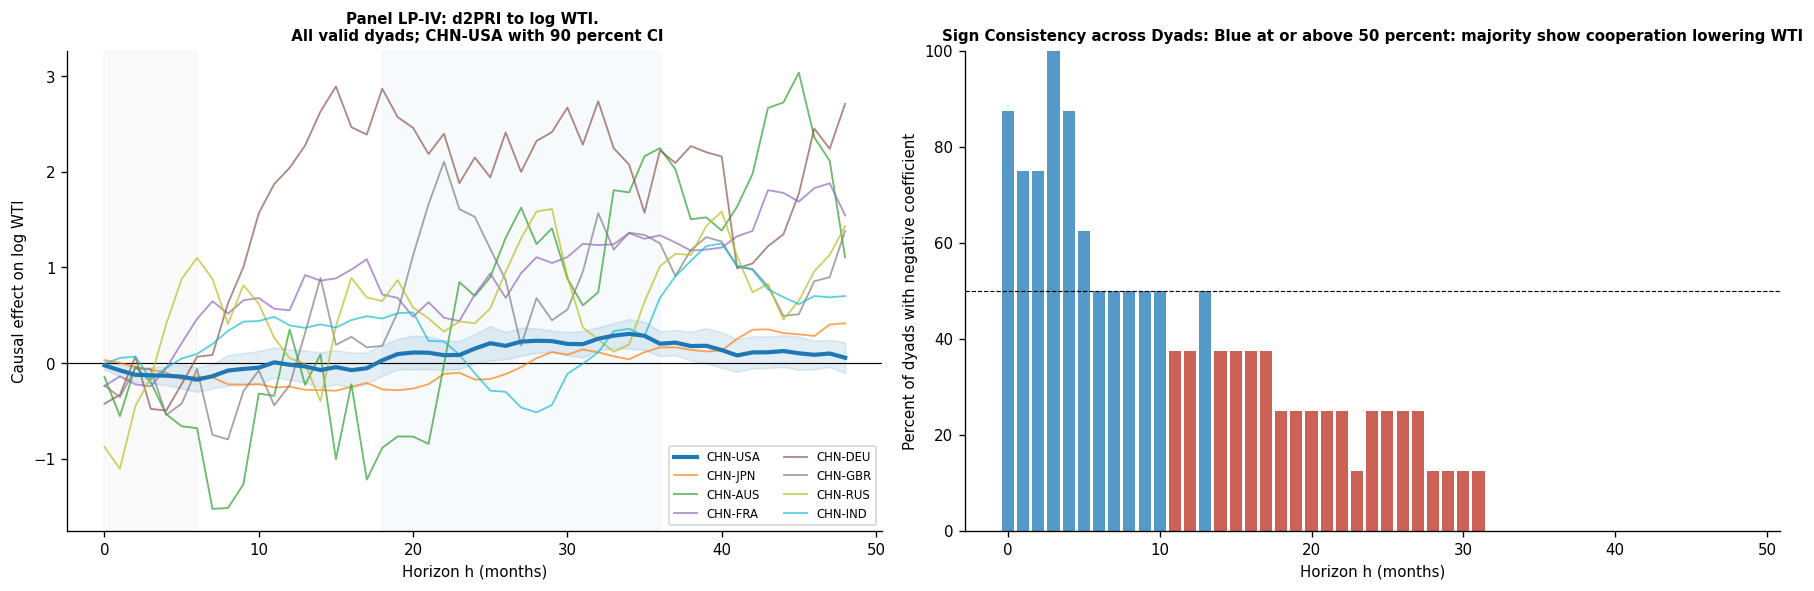

Saved: fig_panel_irf.png


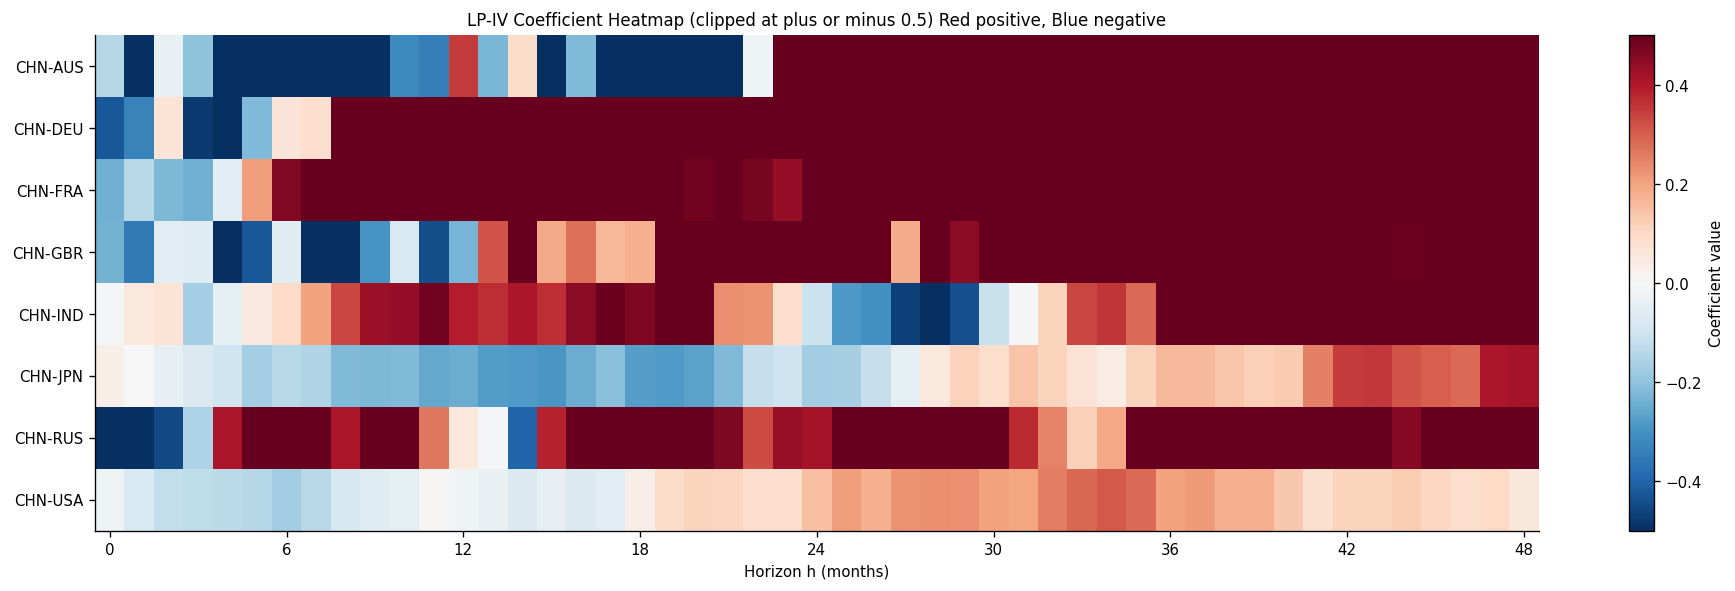

Saved: fig_panel_heatmap.png


In [9]:
all_rows = pd.DataFrame(panel_rows)
palette  = plt.cm.tab10(np.linspace(0, 1, len(irf_store)))

# Figure N1
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.axhline(0, color='black', lw=0.7)
ax.axvspan(0, 6,  alpha=0.04, color='grey')
ax.axvspan(18, 36, alpha=0.04, color='steelblue')
for i, (dyad, irf) in enumerate(irf_store.items()):
    hs  = np.array(irf['h']); cs = np.array(irf['coef']); ses = np.array(irf['se'])
    lw  = 2.5 if dyad == 'CHN-USA' else 1.1
    al  = 1.0 if dyad == 'CHN-USA' else 0.70
    ax.plot(hs, cs, color=palette[i], lw=lw, alpha=al, label=dyad, zorder=3 if dyad=='CHN-USA' else 2)
    if dyad == 'CHN-USA':
        ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.12, color=palette[i])
ax.set_xlabel('Horizon h (months)'); ax.set_ylabel('Causal effect on log WTI')
ax.set_title('Panel LP-IV: d2PRI to log WTI. \n All valid dyads; CHN-USA with 90 percent CI', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, ncol=2)

# Figure N2
ax2 = axes[1]
hz       = sorted(all_rows['h'].unique())
pct_neg  = [100*(all_rows[all_rows['h']==h]['coef']<0).mean() for h in hz]
c_bars   = ['#2980B9' if p>=50 else '#C0392B' for p in pct_neg]
ax2.bar(hz, pct_neg, color=c_bars, alpha=0.8, width=0.8)
ax2.axhline(50, color='black', lw=0.7, ls='--')
ax2.set_ylim(0, 100); ax2.set_xlabel('Horizon h (months)')
ax2.set_ylabel('Percent of dyads with negative coefficient')
ax2.set_title('Sign Consistency across Dyads: Blue at or above 50 percent: majority show cooperation lowering WTI', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/'fig_panel_irf.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: fig_panel_irf.png")

# Figure N3: heatmap
pivot = all_rows.pivot_table(index='dyad', columns='h', values='coef')
fig, ax = plt.subplots(figsize=(16, max(3, len(irf_store)*0.5+1)))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=9)
h_ticks = [i for i,h in enumerate(pivot.columns) if h%6==0]
ax.set_xticks(h_ticks); ax.set_xticklabels([int(pivot.columns[i]) for i in h_ticks])
ax.set_xlabel('Horizon h (months)')
ax.set_title('LP-IV Coefficient Heatmap (clipped at plus or minus 0.5) Red positive, Blue negative', fontsize=10)
plt.colorbar(im, ax=ax, label='Coefficient value')
plt.tight_layout()
plt.savefig(OUT/'fig_panel_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: fig_panel_heatmap.png")


### 3.3 CHN-USA Annotated IRF

This figure overlays the CHN-USA LP-IV impulse response function with vertical markers at key bilateral turning-point dates. The annotations allow qualitative validation: improvement events should fall in months where the subsequent IRF trajectory is in its negative range; deterioration events should fall in months where the subsequent IRF trajectory is in its positive range.

Conflict events are marked in red: Taiwan Strait Crisis (March 1996), NATO embassy bombing (May 1999), EP-3 Hainan Island incident (April 2001), trade war onset (March 2018), COVID-19 diplomatic escalation (April 2020).

Cooperation events are marked in blue: Jiang Zemin state visit to Washington (October 1997), China WTO accession (December 2001).


In [10]:
if 'CHN-USA' in irf_store:
    irf = irf_store['CHN-USA']
    hs  = np.array(irf['h']); cs = np.array(irf['coef']); ses = np.array(irf['se'])
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(hs, cs, 0, where=cs>=0, color='#C0392B', alpha=0.16)
    ax.fill_between(hs, cs, 0, where=cs< 0, color='#2980B9', alpha=0.16)
    ax.plot(hs, cs, color='#2C3E50', lw=2.0, zorder=4)
    ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.12, color='#2980B9')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvspan(0, 6,  alpha=0.05, color='grey')
    ax.axvspan(18, 36, alpha=0.05, color='steelblue')
    ax.set_xlim(0, 48)
    CONFLICT = {'1996-03':'Taiwan Strait','1999-05':'Embassy Bombing','2001-04':'EP-3 Incident','2018-03':'Trade War','2020-04':'COVID Escalation'}
    COOP     = {'1997-10':'Jiang Visit','2001-12':'WTO Accession'}
    ymin, ymax = ax.get_ylim(); yr = ymax - ymin
    for ds, label in CONFLICT.items():
        ax.axvline(pd.Timestamp(ds), color='#C0392B', lw=1.0, ls=':', alpha=0.8)
        ax.text(pd.Timestamp(ds), ymax-0.04*yr, label, rotation=90, fontsize=7, va='top', ha='right', color='#C0392B', fontweight='bold')
    for ds, label in COOP.items():
        ax.axvline(pd.Timestamp(ds), color='#2980B9', lw=1.0, ls=':', alpha=0.8)
        ax.text(pd.Timestamp(ds), ymin+0.04*yr, label, rotation=90, fontsize=7, va='bottom', ha='right', color='#2980B9', fontweight='bold')
    ax.set_xlabel('Horizon h (months)'); ax.set_ylabel('Causal effect on log WTI')
    ax.set_title('CHN-USA LP-IV with Bilateral Event Annotations (1990 to 2022) d2PRI instrument; 90 percent CI; grey short run, blue medium run', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT/'fig_chnusa_irf_annotated.png', dpi=150, bbox_inches='tight')
    plt.show(); print("Saved: fig_chnusa_irf_annotated.png")


Saved: fig_chnusa_irf_annotated.png


### 3.4 Composite GPR as Panel Nuisance Control

The composite GPR index from NB02 aggregates five independent data sources into a dyad-specific measure of bilateral geopolitical stress. This cell tests whether adding the lagged composite GPR as an additional control variable in the LP-IV changes the causal estimates for each valid dyad.

If the composite GPR captures bilateral information that the macro controls miss, its inclusion should shift the causal coefficient for log PRI. Stable coefficients across the two specifications indicate that the baseline macro-only specification is not materially confounded by the NLP information channel, which is the same test performed for CHN-USA in NB05 Section 4.3.

Large deviations for borderline dyads (CHN-IND, CHN-DEU) reflect instrument fragility rather than NLP-driven confounding: adding any additional regressor reduces the effective sample for the IV and can destabilise estimates when F is near 10.

⏱ Approximately 3 minutes.


In [11]:
if cgpr_cols:
    print("Panel LP-IV with composite GPR nuisance")
    print(f"{'Dyad':10s}  {'h=6 base':>10}  {'h=6+cgpr':>10}  {'dev%':>7}")
    print('='*45)
    irf_cgpr = {}
    for _, row in fs_df[fs_df['valid']].iterrows():
        dyad, lpri_col, d2_col = row['dyad'], row['lpri_col'], row['d2_col']
        cgpr_col = f"cgpr_{dyad.replace('-','_')}"
        if cgpr_col not in df.columns or df[cgpr_col].notna().sum() < 50:
            print(f"{dyad:10s}  composite GPR not available for this dyad"); continue
        df[f'{cgpr_col}_l1'] = df[cgpr_col].shift(1)
        extra_ctrl = BASE_CONTROLS + [f'{cgpr_col}_l1']
        irf_c = compute_irf(df, lpri_col, d2_col, extra_ctrl, HORIZONS, f'{dyad}+cgpr')
        irf_cgpr[dyad] = irf_c
        def _gc(irf_d, hh):
            if hh in irf_d.get('h',[]): return irf_d['coef'][irf_d['h'].index(hh)]
        def _gb(hh):
            irf_b = irf_store.get(dyad,{}); return irf_b['coef'][irf_b['h'].index(hh)] if hh in irf_b.get('h',[]) else None
        b6=_gb(6); c6=_gc(irf_c,6)
        dev6 = (c6-b6)/abs(b6)*100 if (b6 and c6 and b6!=0) else float('nan')
        fmt  = lambda v: f'{v:+.4f}' if v is not None else '  n/a'
        print(f"{dyad:10s}  {fmt(b6):>10}  {fmt(c6):>10}  {dev6:>+7.1f}%")
    print("Deviations below 15 percent at h=6 indicate the baseline specification")
    print("is not materially confounded by the NLP information channel.")
else:
    print("Composite GPR columns not available. Run NB02 first.")


Panel LP-IV with composite GPR nuisance
Dyad          h=6 base    h=6+cgpr     dev%
CHN-USA        -0.1740     -0.1640     +5.7%
CHN-JPN        -0.1402     -0.1437     -2.5%
CHN-AUS        -0.6816     -0.6551     +3.9%
CHN-FRA        +0.4622     +0.5376    +16.3%
CHN-DEU        +0.0658     +0.0965    +46.7%
CHN-GBR        -0.0623     -0.0621     +0.2%
CHN-RUS        +1.1015     +1.0177     -7.6%
CHN-IND        +0.0952     +0.0178    -81.4%
Deviations below 15 percent at h=6 indicate the baseline specification
is not materially confounded by the NLP information channel.


---
## 4. Pooled Estimation and External Validity

This section produces three forms of cross-dyad evidence: an inverse-variance-weighted pooled estimator for the three most reliably identified dyads, Anderson-Rubin confidence sets for the four excluded dyads, and a pooled DML with XGBoost nuisance across all eight valid dyads.


### 4.1 Inverse-Variance-Weighted Pooled Estimator

The IVW estimator (Borenstein et al. 2009) combines dyad-specific IRFs into a precision-weighted average:

beta-IVW at h = sum of (beta-dyad divided by sigma-dyad squared) divided by sum of (1 divided by sigma-dyad squared)

**Dyad selection: CHN-USA, CHN-JPN, CHN-GBR.** These three share the oil-import channel (all net oil importers) and have the three strongest instruments. CHN-AUS is excluded from the IVW because its h=36 coefficient shows extreme IV fat-tail behaviour, which would distort the weighted average at medium-run horizons.

⏱ Under 1 minute.


IVW pooled (USA+JPN+GBR): 24/49 sig at 10 percent
  h= 6: beta=-0.1653  se=0.0700  t=-2.36*
  h=12: beta=-0.0782  se=0.0832  t=-0.94
  h=24: beta=+0.1005  se=0.0808  t=+1.24
  h=36: beta=+0.2132  se=0.0762  t=+2.80*


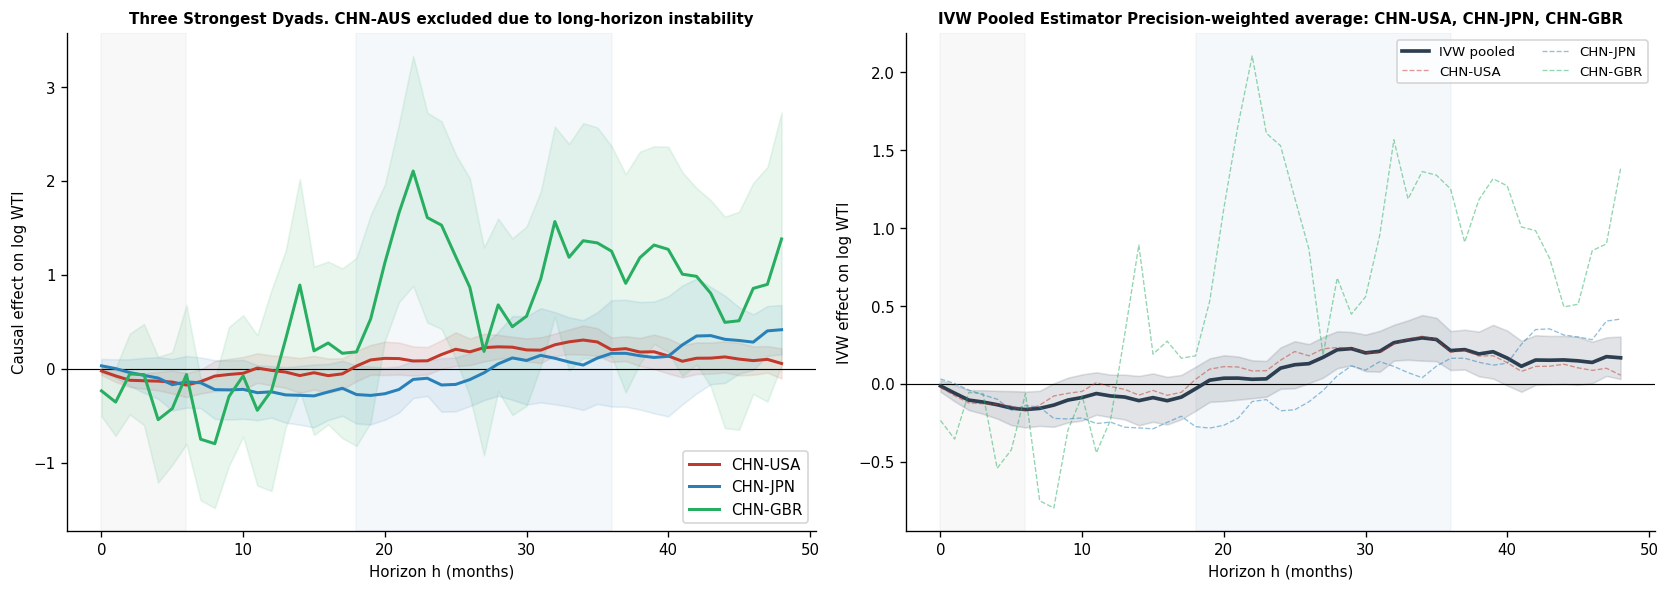

Saved: fig_strong_dyads_ivw.png, irf_ivw_pooled.csv


In [12]:
STRONG_DYADS = ['CHN-USA','CHN-JPN','CHN-GBR']
palette_s    = {'CHN-USA':'#C0392B','CHN-JPN':'#2980B9','CHN-GBR':'#27AE60'}
ivw_h, ivw_c, ivw_se = [], [], []
for h in HORIZONS:
    wts,coefs = [],[]
    for dyad in STRONG_DYADS:
        if dyad not in irf_store or h not in irf_store[dyad]['h']: continue
        idx = irf_store[dyad]['h'].index(h); se = irf_store[dyad]['se'][idx]
        if se>0: wts.append(1/se**2); coefs.append(irf_store[dyad]['coef'][idx])
    if len(wts)<2: continue
    tw = sum(wts)
    ivw_h.append(h); ivw_c.append(sum(w*c for w,c in zip(wts,coefs))/tw); ivw_se.append(1/tw**0.5)

n_sig_ivw = sum(1 for c,se in zip(ivw_c,ivw_se) if se>0 and abs(c/se)>Z90)
print(f"IVW pooled (USA+JPN+GBR): {n_sig_ivw}/{len(ivw_h)} sig at 10 percent")
for hh in [6,12,24,36]:
    if hh in ivw_h:
        idx=ivw_h.index(hh); c=ivw_c[idx]; se=ivw_se[idx]
        print(f"  h={hh:2d}: beta={c:+.4f}  se={se:.4f}  t={c/se:+.2f}{'*' if abs(c/se)>Z90 else ''}")

pd.DataFrame({'h':ivw_h,'coef':ivw_c,'se':ivw_se}).to_csv(OUT/'irf_ivw_pooled.csv',index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.axhline(0, color='black', lw=0.7)
ax.axvspan(0,6,alpha=0.05,color='grey'); ax.axvspan(18,36,alpha=0.05,color='steelblue')
for dyad in STRONG_DYADS:
    if dyad not in irf_store: continue
    irf=irf_store[dyad]; hs=np.array(irf['h']); cs=np.array(irf['coef']); ses=np.array(irf['se'])
    ax.plot(hs,cs,color=palette_s[dyad],lw=1.8,label=dyad)
    ax.fill_between(hs,cs-Z90*ses,cs+Z90*ses,alpha=0.10,color=palette_s[dyad])
ax.set_xlabel('Horizon h (months)'); ax.set_ylabel('Causal effect on log WTI')
ax.set_title('Three Strongest Dyads. CHN-AUS excluded due to long-horizon instability', fontsize=9, fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.axhline(0, color='black', lw=0.7)
ax2.axvspan(0,6,alpha=0.05,color='grey'); ax2.axvspan(18,36,alpha=0.05,color='steelblue')
hs=np.array(ivw_h); cs=np.array(ivw_c); ses=np.array(ivw_se)
ax2.plot(hs,cs,color='#2C3E50',lw=2.2,label='IVW pooled')
ax2.fill_between(hs,cs-Z90*ses,cs+Z90*ses,alpha=0.14,color='#2C3E50')
for dyad in STRONG_DYADS:
    if dyad not in irf_store: continue
    irf=irf_store[dyad]
    ax2.plot(np.array(irf['h']),np.array(irf['coef']),color=palette_s[dyad],lw=0.8,ls='--',alpha=0.5,label=dyad)
ax2.set_xlabel('Horizon h (months)'); ax2.set_ylabel('IVW effect on log WTI')
ax2.set_title('IVW Pooled Estimator Precision-weighted average: CHN-USA, CHN-JPN, CHN-GBR', fontsize=9, fontweight='bold')
ax2.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(OUT/'fig_strong_dyads_ivw.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: fig_strong_dyads_ivw.png, irf_ivw_pooled.csv")


### 4.2 Anderson-Rubin Confidence Sets for Weak-Instrument Dyads

Standard Wald confidence intervals are unreliable when the first-stage F-statistic is below 10. The Anderson-Rubin (1949) procedure provides valid 90 percent confidence sets for any instrument strength level.

The procedure inverts the Anderson-Rubin test: for each candidate structural parameter theta-zero, the reduced-form regression of (Y minus theta-zero times D) on the instrument and controls is estimated, and the F-statistic for the instrument is computed. The 90 percent confidence set collects all theta-zero values where this F-statistic does not reject, meaning the data are compatible with that value of the structural parameter at the 10 percent level.

A confidence set spanning the full search grid from minus 5 to plus 5 means the instrument provides no usable causal information for that dyad. These dyads are excluded from the main panel analysis and from the IVW estimator.

⏱ Approximately 5 minutes.


In [14]:
from scipy.stats import f as f_dist

def ar_ci(df_in, lpri_col, d2_col, controls, h, beta_grid=None, alpha=0.10, min_obs=50):
    if beta_grid is None: beta_grid = np.linspace(-5, 5, 400)
    w = df_in.copy()
    w['_y'] = w['lwti'].shift(-h)
    for l in range(1,4): w[f'_Ly{l}'] = w['lwti'].shift(l)
    lags = [f'_Ly{l}' for l in range(1,4)]
    need = ['_y', lpri_col, d2_col] + lags + controls
    sub  = w[[c for c in need if c in w.columns]].dropna()
    if len(sub) < min_obs: return None, None
    cl   = _prune(sub, lags + controls)
    Xmat = add_constant(sub[[d2_col]+cl], has_constant='add').values
    y_arr= sub['_y'].values; d_arr = sub[lpri_col].values
    n, k = Xmat.shape; crit = f_dist.ppf(1-alpha, 1, n-k)
    accept = []
    for b0 in beta_grid:
        y_t = y_arr - b0*d_arr
        z_res = Xmat[:,0] - Xmat[:,1:]@np.linalg.lstsq(Xmat[:,1:],Xmat[:,0],rcond=None)[0]
        res   = y_t - Xmat[:,1:]@np.linalg.lstsq(Xmat[:,1:],y_t,rcond=None)[0]
        z2    = z_res@z_res
        if z2 < 1e-12: accept.append(True); continue
        num   = (z_res@res)**2/z2; den = (res@res)/max(n-k,1)
        accept.append((num/den if den>0 else np.inf) <= crit)
    accept = np.array(accept); bg = np.array(beta_grid)
    if not accept.any(): return None, None
    return float(bg[accept][0]), float(bg[accept][-1])

WEAK_DYADS = [d for d in DYADS if d not in valid_dyads]
print(f"Weak dyads receiving Anderson-Rubin confidence sets: {WEAK_DYADS}")
print(f"{'Dyad':10s}  {'h':>4}  {'F-stat':>8}  {'AR lower':>9}  {'AR upper':>9}  Width  Note")
print('-'*68)
ar_results = []
for dyad in WEAK_DYADS:
    if dyad not in [r['dyad'] for _,r in fs_df.iterrows()]: continue
    row_fs   = fs_df[fs_df['dyad']==dyad].iloc[0]
    lpri_col = row_fs['lpri_col']; d2_col = row_fs['d2_col']; f_stat = row_fs['F']
    for h_ar in [6, 36]:
        lo, hi = ar_ci(df, lpri_col, d2_col, BASE_CONTROLS, h_ar)
        if lo is None:
            print(f"{dyad:10s}  {h_ar:>4}  {f_stat:>8.2f}  {'EMPTY':>9}  {' ':>9}  ---  all values rejected")
            ar_results.append({'dyad':dyad,'h':h_ar,'f_stat':f_stat,'ar_lo':None,'ar_hi':None})
        else:
            width = hi-lo; spans = (lo<=-4.8 and hi>=4.8)
            print(f"{dyad:10s}  {h_ar:>4}  {f_stat:>8.2f}  {lo:>+9.3f}  {hi:>+9.3f}  {width:>5.2f}  {'no information' if spans else ''}")
            ar_results.append({'dyad':dyad,'h':h_ar,'f_stat':f_stat,'ar_lo':lo,'ar_hi':hi})

pd.DataFrame(ar_results).to_csv(OUT/'ar_ci_weak_dyads.csv', index=False)
print(" Saved: ar_ci_weak_dyads.csv")


Weak dyads receiving Anderson-Rubin confidence sets: ['CHN-IDN', 'CHN-PAK', 'CHN-VNM', 'CHN-KOR']
Dyad           h    F-stat   AR lower   AR upper  Width  Note
--------------------------------------------------------------------
CHN-IDN        6      8.30     +0.038     +0.088   0.05  
CHN-IDN       36      8.30     +0.063     +0.163   0.10  
CHN-PAK        6      7.88     -0.890     -0.163   0.73  
CHN-PAK       36      7.88     -1.692     -0.514   1.18  
CHN-VNM        6      7.99     +0.013     +0.063   0.05  
CHN-VNM       36      7.99     +0.038     +0.113   0.08  
CHN-KOR        6      8.37     +0.013     +0.063   0.05  
CHN-KOR       36      8.37     +0.038     +0.088   0.05  
 Saved: ar_ci_weak_dyads.csv


### 4.3 Pooled Panel DML with XGBoost Nuisance

The individual dyad LP-IV estimates in Section 3.1 treat each bilateral relationship independently and use linear controls. This cell stacks all eight valid dyads into a single long-format panel and estimates pooled Double-Debiased ML (Chernozhukov et al. 2018) with XGBoost nuisance functions.

Pooling provides two advantages over individual LP-IV. First, the combined sample of approximately 3,000 observations allows XGBoost to learn non-linear interactions between macro controls and dyad characteristics that are not estimable from any single dyad. Second, dyad fixed effects are absorbed by including seven dyad indicator dummies in the nuisance functions, which is the ML analogue of within-dyad demeaning in linear panel models.

Cross-fitting uses TimeSeriesSplit on the pooled panel sorted by date then dyad. This ensures training folds strictly precede test folds chronologically for each dyad.

⏱ 20 to 30 minutes.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    def _make_learner(d=3):
        return XGBRegressor(n_estimators=200, max_depth=d, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbosity=0, n_jobs=1)
    LEARNER_LABEL = "XGBoost (depth=3)"
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    def _make_learner(d=3):
        return GradientBoostingRegressor(n_estimators=200, max_depth=d,
                                          learning_rate=0.05, random_state=42)
    LEARNER_LABEL = "GradientBoosting (depth=3)"
print(f"DML learner: {LEARNER_LABEL}")

# Stack valid dyads
long_rows = []
for dyad, (lpri_col, d2_col, _) in DYADS.items():
    if dyad not in valid_dyads: continue
    needed = ['date','lwti'] + BASE_CONTROLS + [lpri_col, d2_col]
    sub = df[[c for c in needed if c in df.columns]].copy()
    sub = sub.rename(columns={lpri_col:'lpri_panel', d2_col:'d2pri_panel'})
    sub['dyad'] = dyad; long_rows.append(sub)
panel = pd.concat(long_rows, ignore_index=True).sort_values(['date','dyad']).reset_index(drop=True)
panel = panel.dropna(subset=['lpri_panel','d2pri_panel','lwti']+BASE_CONTROLS)
dyad_dummies = pd.get_dummies(panel['dyad'], prefix='dyad', drop_first=True, dtype=float)
dyad_cols    = dyad_dummies.columns.tolist()
panel        = pd.concat([panel, dyad_dummies], axis=1)
DML_NUIS_PANEL = BASE_CONTROLS + dyad_cols
print(f"Panel: {panel.shape}  dyads: {panel['dyad'].unique().tolist()}")

def panel_dml_at_h(data, h, nuisance_controls, lp_controls, n_splits=5, min_obs=200):
    w = data.copy()
    for l in range(1,4): w[f'_Ly{l}'] = w.groupby('dyad')['lwti'].shift(l)
    for l in range(1,3): w[f'_Lt{l}'] = w.groupby('dyad')['lpri_panel'].shift(l)
    w['_y']  = w.groupby('dyad')['lwti'].shift(-h)
    lags     = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
    nuis_cl  = [c for c in lags+nuisance_controls if c in w.columns]
    full_cl  = [c for c in lags+lp_controls if c in w.columns]
    need     = ['_y','lpri_panel','d2pri_panel'] + list(set(nuis_cl+full_cl))
    sub      = w[[c for c in need if c in w.columns]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(sub) < min_obs: return None, None, 0
    nuis_cl  = _prune(sub, nuis_cl)
    X_nuis   = sub[nuis_cl].values
    Y=sub['_y'].values; T=sub['lpri_panel'].values; Z=sub['d2pri_panel'].values
    tss = TimeSeriesSplit(n_splits=n_splits)
    eY = np.full(len(sub),np.nan); eT = np.full(len(sub),np.nan); eZ = np.full(len(sub),np.nan)
    for tr,te in tss.split(X_nuis):
        if len(tr)<50: continue
        sc=StandardScaler(); Xtr=sc.fit_transform(X_nuis[tr]); Xte=sc.transform(X_nuis[te])
        for arr,ea in [(Y,eY),(T,eT),(Z,eZ)]:
            m=_make_learner(3); m.fit(Xtr,arr[tr]); ea[te]=arr[te]-m.predict(Xte)
    valid = ~np.isnan(eY)
    if valid.sum()<100: return None, None, 0
    sr = pd.DataFrame({'eY':eY[valid],'eT':eT[valid],'eZ':eZ[valid]},index=sub.index[valid])
    sr['const'] = 1.0
    lp_cl_clean = _prune(sub.iloc[valid], full_cl)
    for col in lp_cl_clean: sr[col] = sub.iloc[valid][col].values
    try:
        fit = IV2SLS(sr['eY'], sr[['const']+lp_cl_clean], sr[['eT']], sr[['eZ']]).fit(cov_type='kernel')
        return float(fit.params['eT']), float(fit.std_errors['eT']), int(valid.sum())
    except: return None, None, 0

KEY_H = [3, 6, 12, 18, 24, 36]
irf_panel_dml = {'label':f'Pooled Panel DML ({LEARNER_LABEL})','h':[],'coef':[],'se':[],'n':[]}
print(f" Running pooled panel DML...")
for h in KEY_H:
    print(f"  h={h}...", end=" ", flush=True)
    c,se,n = panel_dml_at_h(panel, h, DML_NUIS_PANEL, DML_NUIS_PANEL)
    if c is not None:
        irf_panel_dml['h'].append(h); irf_panel_dml['coef'].append(c); irf_panel_dml['se'].append(se); irf_panel_dml['n'].append(n)
        print(f"beta={c:+.4f}{'*' if se>0 and abs(c/se)>Z90 else ''}  se={se:.4f}  n={n}")
    else: print("skipped (insufficient obs)")

print(f"{'h':>4}  {'IVW pooled':>12}  {'Panel DML':>12}  {'CHN-USA LP-IV':>14}")
print('-'*48)
for h in KEY_H:
    ivw_c_h = ivw_c[ivw_h.index(h)] if h in ivw_h else None
    dml_c_h = irf_panel_dml['coef'][irf_panel_dml['h'].index(h)] if h in irf_panel_dml['h'] else None
    usa     = irf_store.get('CHN-USA',{}); usa_c_h = usa['coef'][usa['h'].index(h)] if h in usa.get('h',[]) else None
    _f = lambda v: f'{v:>+10.4f}' if v is not None else '        n/a'
    print(f'{h:>4}  {_f(ivw_c_h):>12}  {_f(dml_c_h):>12}  {_f(usa_c_h):>14}')
pd.DataFrame({k:irf_panel_dml[k] for k in ['h','coef','se','n']}).to_csv(OUT/'irf_panel_dml.csv',index=False)
print('Saved: irf_panel_dml.csv')


DML learner: XGBoost (depth=3)
Panel: (3074, 16)  dyads: ['CHN-JPN', 'CHN-USA', 'CHN-AUS', 'CHN-DEU', 'CHN-FRA', 'CHN-GBR', 'CHN-IND', 'CHN-RUS']
 Running pooled panel DML...
  h=3... beta=-0.4967*  se=0.2046  n=2520
  h=6... beta=-0.3427*  se=0.1252  n=2500
  h=12... beta=-0.2455*  se=0.0798  n=2460
  h=18... beta=-0.2705*  se=0.1241  n=2420
  h=24... beta=+0.0172  se=0.1038  n=2380
  h=36... 

---
## 5. Macro Transmission Channels

This section runs the LP-IV with alternative outcome variables to determine whether bilateral geopolitical turning points transmit through commodity pricing alone or also through financial uncertainty and real activity channels.

**Causal interpretation scope.** The exclusion restriction (d2PRI affects the outcome only through the bilateral diplomatic channel) is most defensible for WTI and Brent. For VIX and industrial production, reverse causality cannot be fully ruled out. Results for non-oil outcomes are reported as conditional associations under the maintained identification assumption and should not be interpreted as structural causal effects without additional justification.

⏱ Approximately 5 minutes.


In [ ]:
print("Checking available outcome variables:")
OUTCOMES = {}
for col, label in [('lwti','Log WTI crude'),('brent','Brent crude'),('indpro','US Indus. Prod.'),('vix','VIX'),('cny_usd','CNY/USD rate')]:
    if col in df.columns and df[col].notna().sum() > 100:
        OUTCOMES[col] = label; print(f"  {col}: available ({df[col].notna().sum()} obs)")
    else: print(f"  {col}: not available")

irf_outcomes = {}
print(f"{'Outcome':22s}  {'sig':>6}  {'h=6':>10}  {'h=12':>10}  {'h=24':>10}")
print('-'*65)
for oc, label in OUTCOMES.items():
    irf_o = {'label':label,'h':[],'coef':[],'se':[],'n':[]}
    for h in HORIZONS:
        w = df.copy(); w['_y'] = w[oc].shift(-h)
        for l in range(1,4): w[f'_Ly{l}'] = w[oc].shift(l)
        for l in range(1,3): w[f'_Lt{l}'] = w['lpri'].shift(l)
        lags    = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
        iv_ctrl = [c for c in BASE_CONTROLS if not c.startswith('_Lt')]
        need    = ['_y','lpri','d2pri'] + lags + iv_ctrl
        sub     = w[[c for c in need if c in w.columns]].replace([np.inf,-np.inf],np.nan).dropna()
        if len(sub) < 60: continue
        cl = _prune(sub, lags+iv_ctrl); exog = sub[cl].copy(); exog.insert(0,'const',1.0)
        try:
            fit = IV2SLS(sub['_y'], exog, sub[['lpri']], sub[['d2pri']]).fit(cov_type='kernel')
            irf_o['h'].append(h); irf_o['coef'].append(float(fit.params['lpri']))
            irf_o['se'].append(float(fit.std_errors['lpri'])); irf_o['n'].append(len(sub))
        except: pass
    irf_outcomes[oc] = irf_o
    n_sig = sum(1 for c,se in zip(irf_o['coef'],irf_o['se']) if se>0 and abs(c/se)>Z90)
    def _g(hh):
        if hh in irf_o['h']:
            idx=irf_o['h'].index(hh); c,se=irf_o['coef'][idx],irf_o['se'][idx]
            return f"{c:+.4f}{'*' if se>0 and abs(c/se)>Z90 else ' '}"
        return '   n/a'
    print(f"{label:22s}  {n_sig:>4}/{len(irf_o['h'])}  {_g(6):>10}  {_g(12):>10}  {_g(24):>10}")

palette_o = ['#2980B9','#C0392B','#27AE60','#8E44AD','#E67E22']
fig, ax = plt.subplots(figsize=(13, 5))
ax.axhline(0, color='black', lw=0.8)
ax.axvspan(0,6,alpha=0.05,color='grey'); ax.axvspan(18,36,alpha=0.05,color='steelblue')
for (oc, irf_o), color in zip(irf_outcomes.items(), palette_o):
    hs=np.array(irf_o['h']); cs=np.array(irf_o['coef']); ses=np.array(irf_o['se'])
    ax.plot(hs, cs, lw=1.8, color=color, label=irf_o['label'])
    ax.fill_between(hs, cs-Z90*ses, cs+Z90*ses, alpha=0.08, color=color)
ax.set_xlabel('Horizon h (months)'); ax.set_ylabel('Effect on outcome')
ax.set_title('CHN-USA LP-IV: Multi-Outcome Impulse Responses, d2PRI instrument; 90 percent CI bands; grey short run, blue medium run', fontsize=9, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(OUT/'fig_multi_outcome_irf.png', dpi=150, bbox_inches='tight')
plt.show()
for col, irf_o in irf_outcomes.items():
    pd.DataFrame({k:irf_o[k] for k in ['h','coef','se','n']}).to_csv(OUT/f'irf_outcome_{col}.csv',index=False)
print("Saved: fig_multi_outcome_irf.png, irf_outcome_*.csv")
